# Tarea Semanal 2
## Autor: Pedro Guzman


### Consigna 

Desarrollar un algoritmo que calcule la transformada discreta de Fourier (DFT).

$X_k=\sum_{n=0}^{N-1}x_n.e^{-j\,2\pi.k.n/N}$

XX = mi_funcion_DFT( xx )

xx: señal a analizar, una matriz (Nx1) de números reales. 
XX: DFT de xx, una matriz (Nx1) de números complejos.

### Bonus


* 💎 Probar las mismas experiencias con la transformada rápida de Fourier (DFT rápida se llama FFT).
* 🤯 Calcular la DFT de una señal aleatoria, por ejemplo ruido uniforme de varianza σ² = 4. Pueden encontrar cómo depende la varianza de los parámetros de la distribución aquí.

### Solucion Propuesta

#### Imports y funciones generales

In [1]:
#Imports
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sp
import time
from scipy.fft import fft, ifft

In [2]:
#Funcion del generador de se;ales
def  mi_funcion ( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 50, type_s = 'sine', duty = 0.5, vmed=5e-3, vsigma=0.5e-3) :
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    if   type_s == 'sine' :
        xx = vmax*np.sin(2*np.pi*ff*tt+ph)+dc
    elif type_s == 'sawtooth' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph)+dc
    elif type_s == 'triangle' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph,width = 0.5)+dc
    elif type_s == 'invsawtooth' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph, width = 0)+dc
    elif type_s == 'square' :
        xx = vmax*sp.square(2*np.pi*ff*tt+ph, duty = duty)+dc
    elif type_s == 'noise_normal' :
        xx = np.random.normal(vmed, vsigma, len(tt))+dc
    elif type_s == 'noise_uniform':
        a = vmed - vsigma * np.sqrt(3)
        b = vmed + vsigma * np.sqrt(3)
        xx = np.random.uniform(a, b, len(tt)) + dc
    else :
        print("Tipo de funcion no existente o incorrecta")
    
    return tt, xx

#Funcion del generador de se;ales
def  mi_generador_ruidoso ( Psine = 1,R = 1 ,SNRdB=10, ff = 1, ph = 0, nn = 100, fs = 50) :
    vmax=np.sqrt(Psine*2*R)
    Pnoise=Psine/(10**(SNRdB/10))
    vsigma=np.sqrt(Pnoise*R)
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    _, xx_sine = mi_funcion( vmax = vmax, dc = 0, ff = ff, ph= ph, nn = nn, fs = fs, type_s = 'sine')
    _ ,xx_noise = mi_funcion( vmed = 0, vsigma = vsigma, nn = nn, fs = fs, type_s = 'noise_normal')
    xx= xx_sine + xx_noise
    SNR_real = 10 * np.log10(Psine / np.var(xx_noise))
    print(f"SNR real: {SNR_real:.9f} dB")
    return tt, xx

In [3]:
def DFT(x):
    
    N=len(x)
    n = np.arange(N)
    k=n.reshape((N,1)) #Vector fila a Vector columna
    e=np.exp(-2j*np.pi*k*n/N)
    Xk=np.dot(x,e) #Producto Punto.
    
    return Xk 

#### Senal Senoidal de entrada

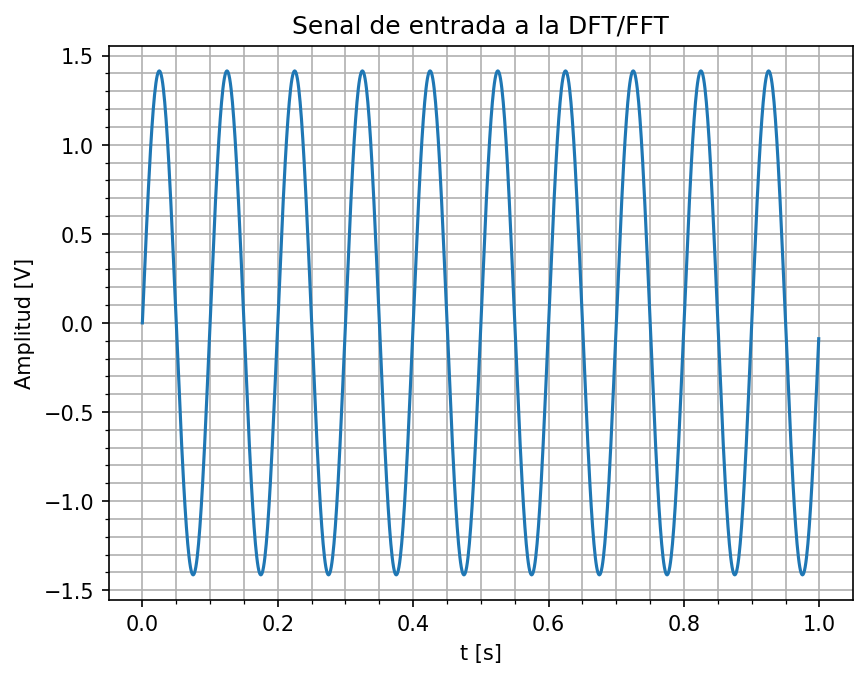

In [4]:
N=1000
fs   = N #Resolucion espectral normalizada
deltaf=fs/N
ff = deltaf*10

t, x = mi_funcion( vmax = np.sqrt(2), dc = 0, ff = ff, ph = 0, nn = N, fs = fs, type_s = 'sine')
plt.figure(dpi=150)
plt.plot(t,x)
plt.minorticks_on()
#plt.xlim([0, 3/ff])
plt.xlabel('t [s]')
plt.ylabel('Amplitud [V]')
plt.title('Senal de entrada a la DFT/FFT')
plt.grid(which = 'major', linestyle = '-', linewidth = 0.8)
plt.grid(which = 'minor', linestyle = '-', linewidth = 0.8)


In [5]:

inicio = time.time()

Xk = DFT(x)

fin = time.time()

timedft = fin - inicio

print(f"Tiempo de ejecución DFT: {fin - inicio:.9f} segundos")


inicio = time.time()

Xft = fft(x)

fin = time.time()

timefft = fin - inicio

print(f"Tiempo de ejecución FFT: {fin - inicio:.9f} segundos")

print(f"Ganancia de Procecsamiento: {timedft/timefft:.9f}")

Tiempo de ejecución DFT: 0.070107222 segundos
Tiempo de ejecución FFT: 0.000348091 segundos
Ganancia de Procecsamiento: 201.404794521


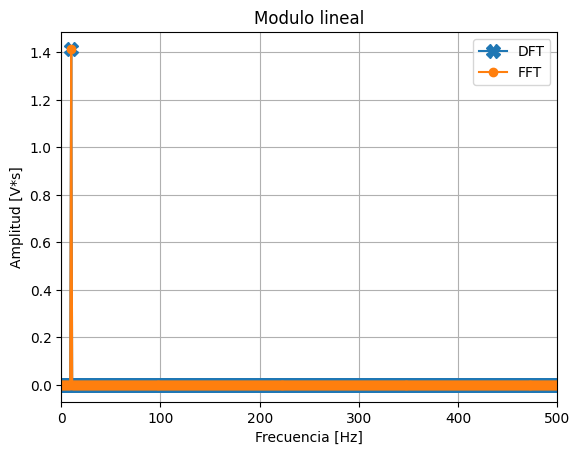

In [6]:
freq= np.arange(start = 0, stop = fs, step = deltaf)

plt.figure()
plt.title("Modulo lineal")
plt.plot(freq,2*np.abs(Xk)/len(Xk), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,2*np.abs(Xft)/len(Xft), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [V*s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

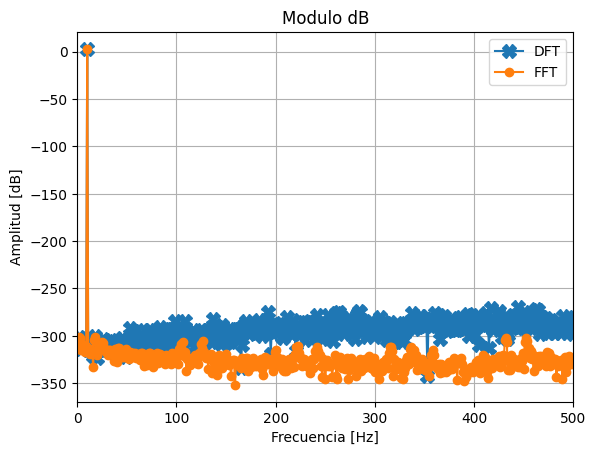

In [7]:
plt.figure()
plt.title("Modulo dB")
plt.plot(freq,20*np.log10(2*np.abs(Xk)/len(Xk)), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,20*np.log10(2*np.abs(Xft)/len(Xft)), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

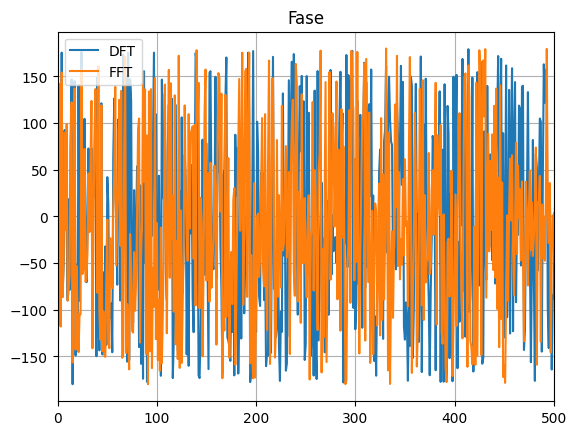

In [8]:
plt.figure()
plt.title("Fase")
plt.plot(freq,np.angle(Xk,deg=True), label= "DFT" )
plt.plot(freq,np.angle(Xft,deg=True), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

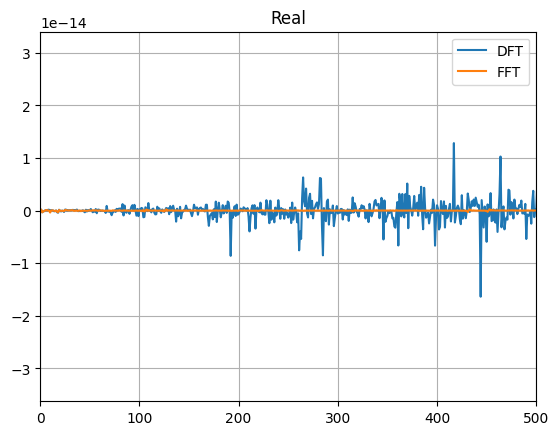

In [9]:
plt.figure()
plt.title("Real")
plt.plot(np.real(Xk)/len(Xk), label= "DFT" )
plt.plot(np.real(Xft)/len(Xft), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

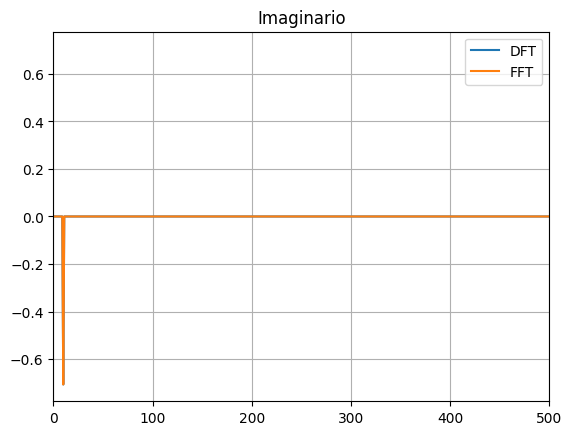

In [10]:
plt.figure()
plt.title("Imaginario")
plt.plot(freq,np.imag(Xk)/len(Xk), label= "DFT" ,markersize= 10)
plt.plot(freq,np.imag(Xft)/len(Xft), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

Se puede ver como los resultados son coincidentes con la realidad, ya que la FFT/DFT de una funcion senoidal pura tiene parte puramente compleja

#### Senal Cosenoidal de entrada

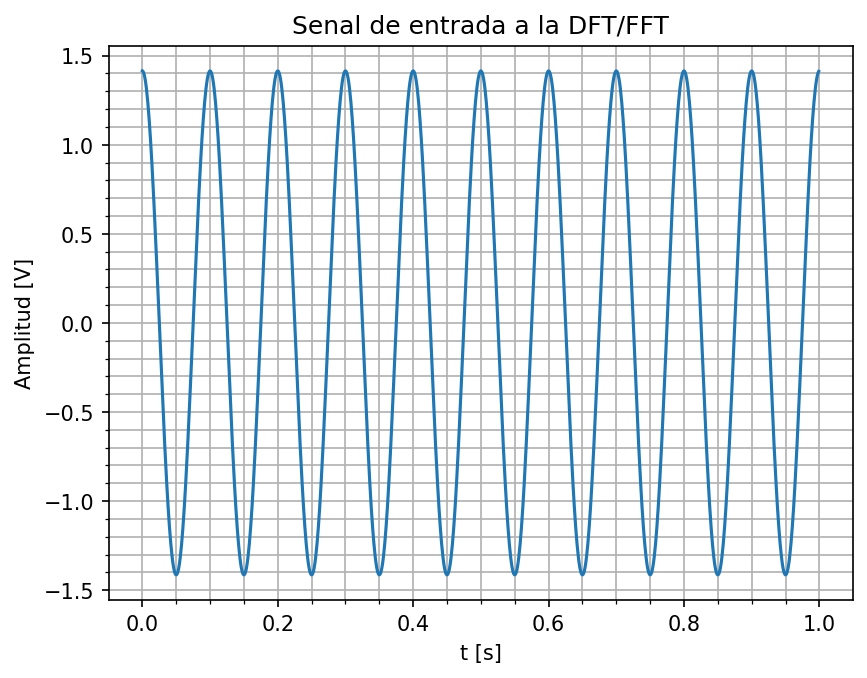

In [11]:
N=1000
fs   = N #Resolucion espectral normalizada
deltaf=fs/N
ff = deltaf*10

t, x = mi_funcion( vmax = np.sqrt(2), dc = 0, ff = ff, ph = np.pi/2, nn = N, fs = fs, type_s = 'sine')
plt.figure(dpi=150)
plt.plot(t,x)
plt.minorticks_on()
#plt.xlim([0, 3/ff])
plt.xlabel('t [s]')
plt.ylabel('Amplitud [V]')
plt.title('Senal de entrada a la DFT/FFT')
plt.grid(which = 'major', linestyle = '-', linewidth = 0.8)
plt.grid(which = 'minor', linestyle = '-', linewidth = 0.8)

In [12]:

inicio = time.time()

Xk = DFT(x)

fin = time.time()

timedft = fin - inicio

print(f"Tiempo de ejecución DFT: {fin - inicio:.9f} segundos")


inicio = time.time()

Xft = fft(x)

fin = time.time()

timefft = fin - inicio

print(f"Tiempo de ejecución FFT: {fin - inicio:.9f} segundos")

print(f"Ganancia de Procecsamiento: {timedft/timefft:.9f}")

Tiempo de ejecución DFT: 0.079485178 segundos
Tiempo de ejecución FFT: 0.000231981 segundos
Ganancia de Procecsamiento: 342.636176773


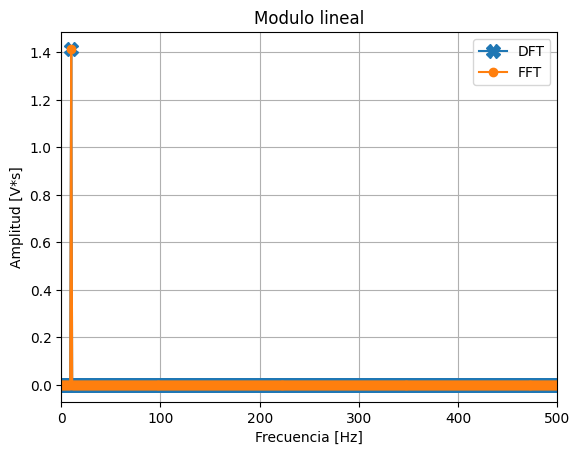

In [13]:
freq= np.arange(start = 0, stop = fs, step = deltaf)

plt.figure()
plt.title("Modulo lineal")
plt.plot(freq,2*np.abs(Xk)/len(Xk), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,2*np.abs(Xft)/len(Xft), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [V*s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

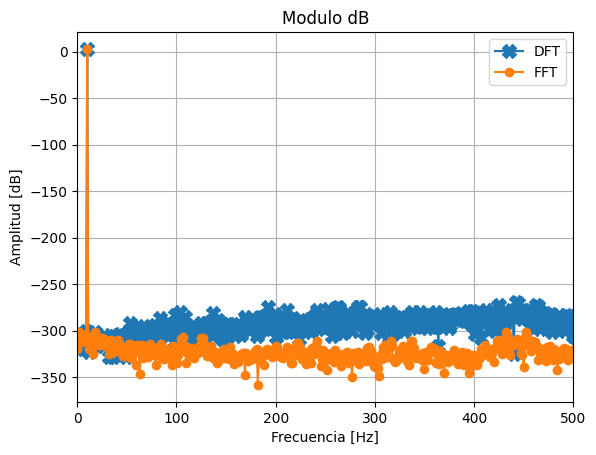

In [14]:
plt.figure()
plt.title("Modulo dB")
plt.plot(freq,20*np.log10(2*np.abs(Xk)/len(Xk)), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,20*np.log10(2*np.abs(Xft)/len(Xft)), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

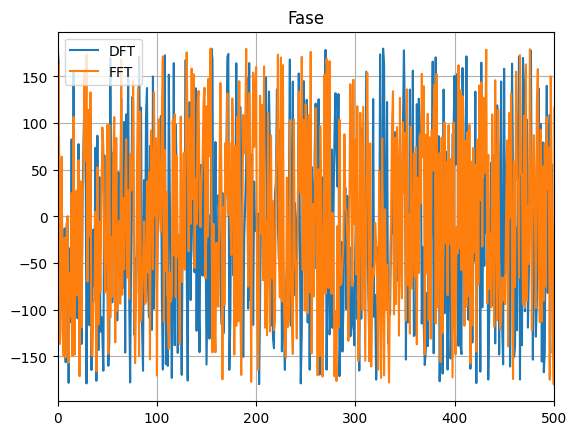

In [15]:
plt.figure()
plt.title("Fase")
plt.plot(freq,np.angle(Xk,deg=True), label= "DFT" )
plt.plot(freq,np.angle(Xft,deg=True), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

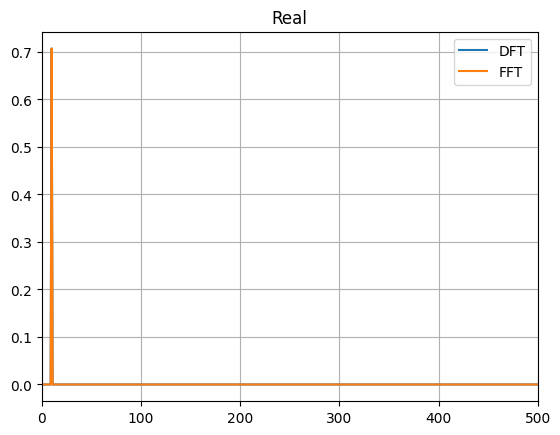

In [16]:
plt.figure()
plt.title("Real")
plt.plot(np.real(Xk)/len(Xk), label= "DFT",markersize= 10 )
plt.plot(np.real(Xft)/len(Xft), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

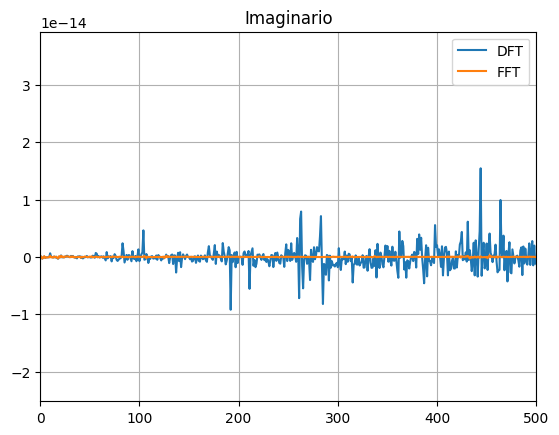

In [17]:
plt.figure()
plt.title("Imaginario")
plt.plot(freq,np.imag(Xk)/len(Xk), label= "DFT" ,markersize= 10)
plt.plot(freq,np.imag(Xft)/len(Xft), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

Se puede ver como los resultados son coincidentes con la realidad, ya que la FFT/DFT de una funcion cosenoidal pura tiene parte puramente real

#### Senal Senoidal de entrada desfasada

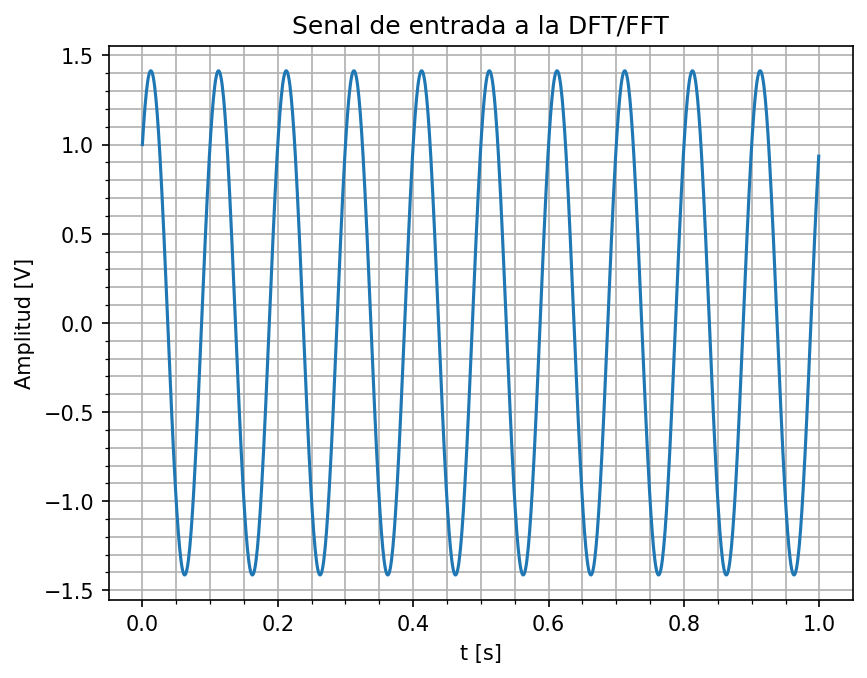

In [18]:
N=1000
fs   = N #Resolucion espectral normalizada
deltaf=fs/N
ff = deltaf*10

t, x = mi_funcion( vmax = np.sqrt(2), dc = 0, ff = ff, ph = np.pi/4, nn = N, fs = fs, type_s = 'sine')
plt.figure(dpi=150)
plt.plot(t,x)
plt.minorticks_on()
#plt.xlim([0, 3/ff])
plt.xlabel('t [s]')
plt.ylabel('Amplitud [V]')
plt.title('Senal de entrada a la DFT/FFT')
plt.grid(which = 'major', linestyle = '-', linewidth = 0.8)
plt.grid(which = 'minor', linestyle = '-', linewidth = 0.8)

In [19]:

inicio = time.time()

Xk = DFT(x)

fin = time.time()

timedft = fin - inicio

print(f"Tiempo de ejecución DFT: {fin - inicio:.9f} segundos")


inicio = time.time()

Xft = fft(x)

fin = time.time()

timefft = fin - inicio

print(f"Tiempo de ejecución FFT: {fin - inicio:.9f} segundos")

print(f"Ganancia de Procecsamiento: {timedft/timefft:.9f}")

Tiempo de ejecución DFT: 0.076379061 segundos
Tiempo de ejecución FFT: 0.000227690 segundos
Ganancia de Procecsamiento: 335.452356021


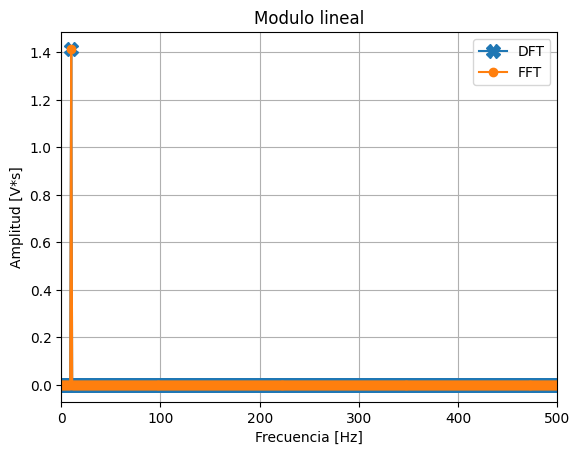

In [20]:
freq= np.arange(start = 0, stop = fs, step = deltaf)

plt.figure()
plt.title("Modulo lineal")
plt.plot(freq,2*np.abs(Xk)/len(Xk), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,2*np.abs(Xft)/len(Xft), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [V*s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

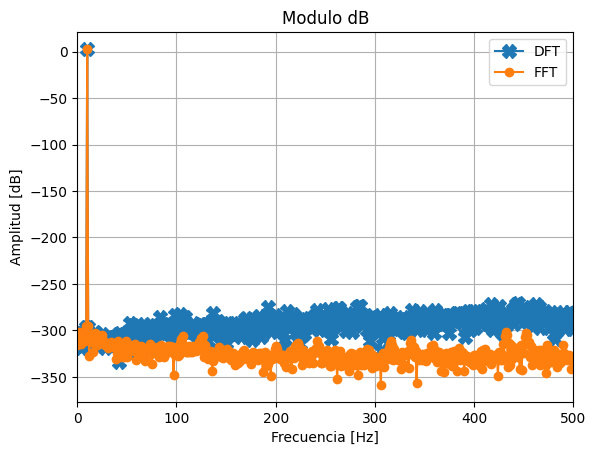

In [21]:
plt.figure()
plt.title("Modulo dB")
plt.plot(freq,20*np.log10(2*np.abs(Xk)/len(Xk)), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,20*np.log10(2*np.abs(Xft)/len(Xft)), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

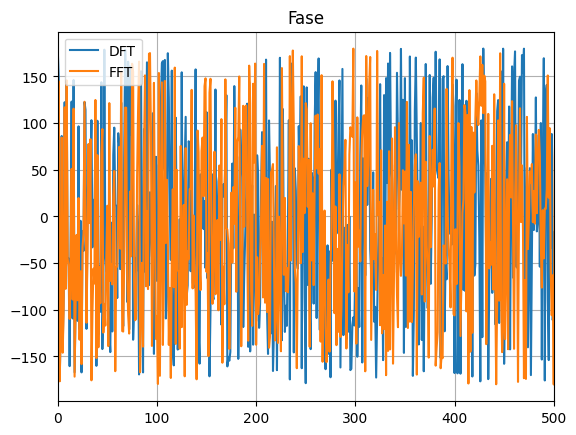

In [22]:
plt.figure()
plt.title("Fase")
plt.plot(freq,np.angle(Xk,deg=True), label= "DFT" )
plt.plot(freq,np.angle(Xft,deg=True), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

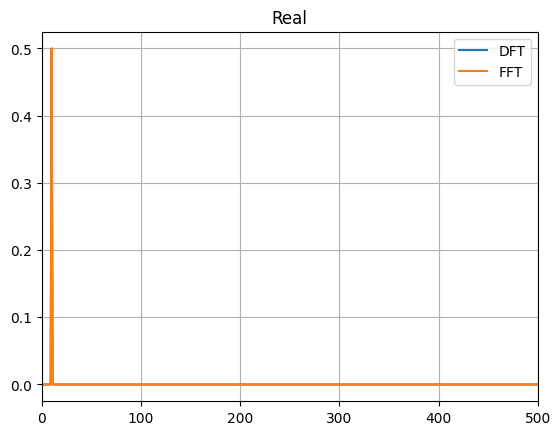

In [23]:
plt.figure()
plt.title("Real")
plt.plot(freq,np.real(Xk)/len(Xk), label= "DFT",markersize= 10 )
plt.plot(freq,np.real(Xft)/len(Xft), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

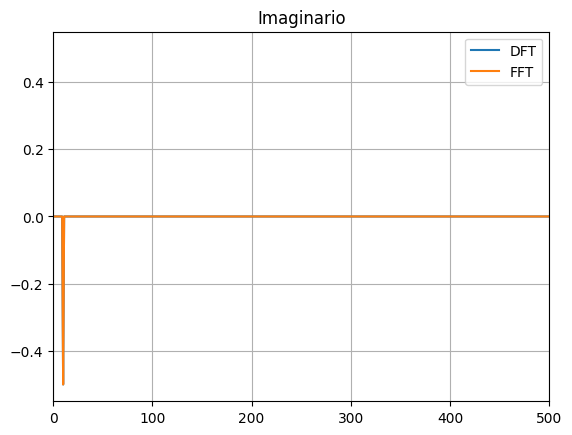

In [24]:
plt.figure()
plt.title("Imaginario")
plt.plot(freq,np.imag(Xk)/len(Xk), label= "DFT" ,markersize= 10)
plt.plot(freq,np.imag(Xft)/len(Xft), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

Se puede ver como los resultados son coincidentes con la realidad, ya que la FFT/DFT de una funcion senoidal desfasada tiene parte real y parte compleja, de la misma magnitud deberia ser este caso debido al desfase simetrico, el mismo no se refleja porque la senal no en tiempo no cierra exactamente donde empieza

#### Ruido con distribucion uniforme
Procedo a resolver el bonus

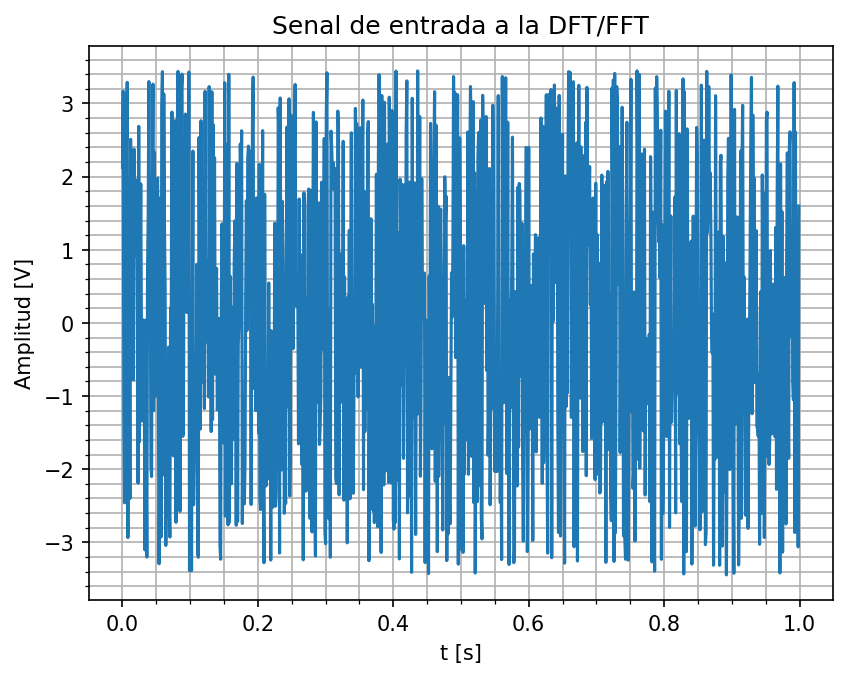

In [25]:
N=1000
fs   = N #Resolucion espectral normalizada
deltaf=fs/N
ff = deltaf*10

t, x = mi_funcion(type_s='noise_uniform', vmed=0, vsigma=2, nn=N, fs=fs)
plt.figure(dpi=150)
plt.plot(t,x)
plt.minorticks_on()
#plt.xlim([0, 3/ff])
plt.xlabel('t [s]')
plt.ylabel('Amplitud [V]')
plt.title('Senal de entrada a la DFT/FFT')
plt.grid(which = 'major', linestyle = '-', linewidth = 0.8)
plt.grid(which = 'minor', linestyle = '-', linewidth = 0.8)

In [26]:
inicio = time.time()

Xk = DFT(x)

fin = time.time()

timedft = fin - inicio

print(f"Tiempo de ejecución DFT: {fin - inicio:.9f} segundos")


inicio = time.time()

Xft = fft(x)

fin = time.time()

timefft = fin - inicio

print(f"Tiempo de ejecución FFT: {fin - inicio:.9f} segundos")

print(f"Ganancia de Procecsamiento: {timedft/timefft:.9f}")

Tiempo de ejecución DFT: 0.078859568 segundos
Tiempo de ejecución FFT: 0.000234365 segundos
Ganancia de Procecsamiento: 336.481180061


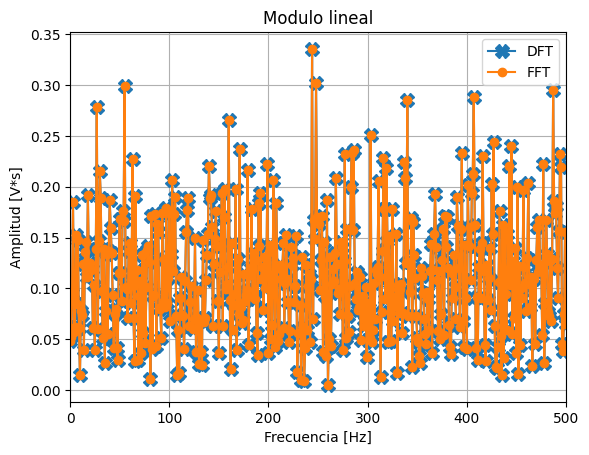

In [27]:
freq= np.arange(start = 0, stop = fs, step = deltaf)

plt.figure()
plt.title("Modulo lineal")
plt.plot(freq,2*np.abs(Xk)/len(Xk), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,2*np.abs(Xft)/len(Xft), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [V*s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

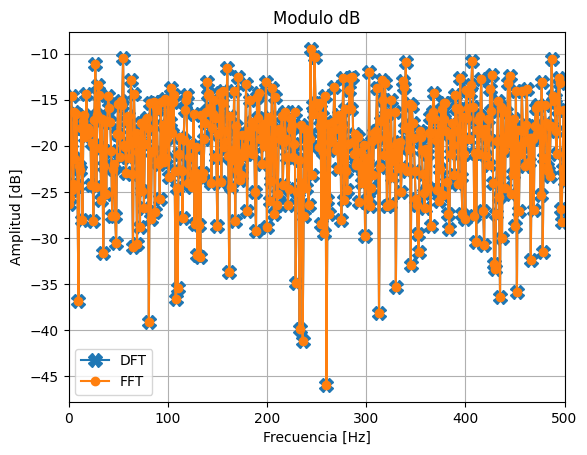

In [28]:
plt.figure()
plt.title("Modulo dB")
plt.plot(freq,20*np.log10(2*np.abs(Xk)/len(Xk)), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,20*np.log10(2*np.abs(Xft)/len(Xft)), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

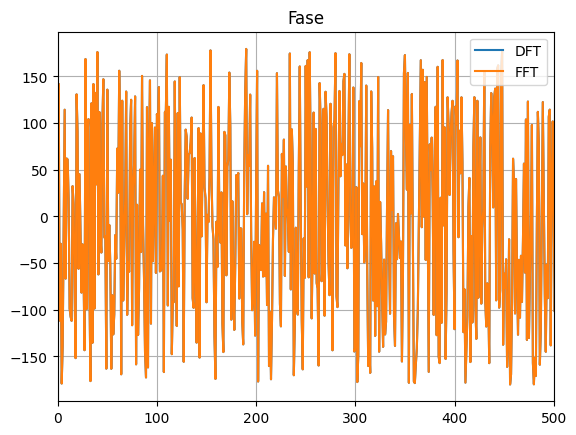

In [29]:
plt.figure()
plt.title("Fase")
plt.plot(freq,np.angle(Xk,deg=True), label= "DFT" ,markersize= 10)
plt.plot(freq,np.angle(Xft,deg=True), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

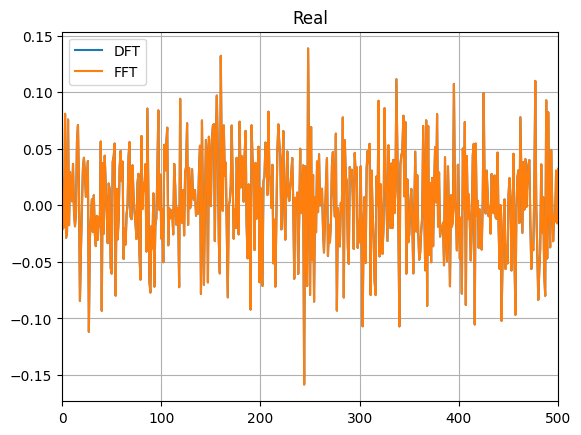

In [30]:
plt.figure()
plt.title("Real")
plt.plot(freq,np.real(Xk)/len(Xk), label= "DFT" ,markersize= 10)
plt.plot(freq,np.real(Xft)/len(Xft), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

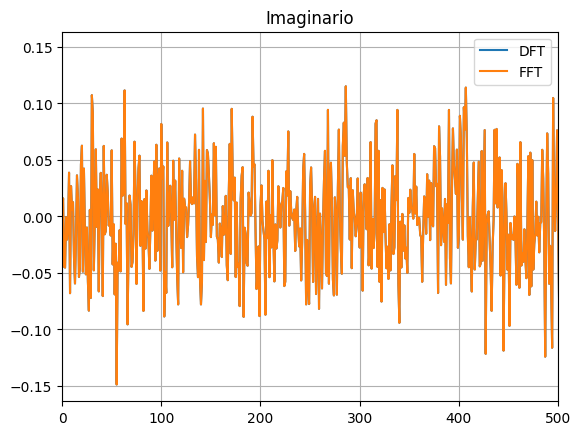

In [31]:
plt.figure()
plt.title("Imaginario")
plt.plot(freq,np.imag(Xk)/len(Xk), label= "DFT" ,markersize= 10)
plt.plot(freq,np.imag(Xft)/len(Xft), label= "FFT")
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

In [32]:
def espectro_promediado(M, N=1000, fs=1000, vmed=0, vsigma=2):

    acum = np.zeros(N)
    for _ in range(M):
        _, x_i = mi_funcion(type_s='noise_uniform', vmed=vmed, vsigma=vsigma, nn=N, fs=fs)
        Xft_i  = fft(x_i)
        acum  += 2 * np.abs(Xft_i) / N

    return acum / M

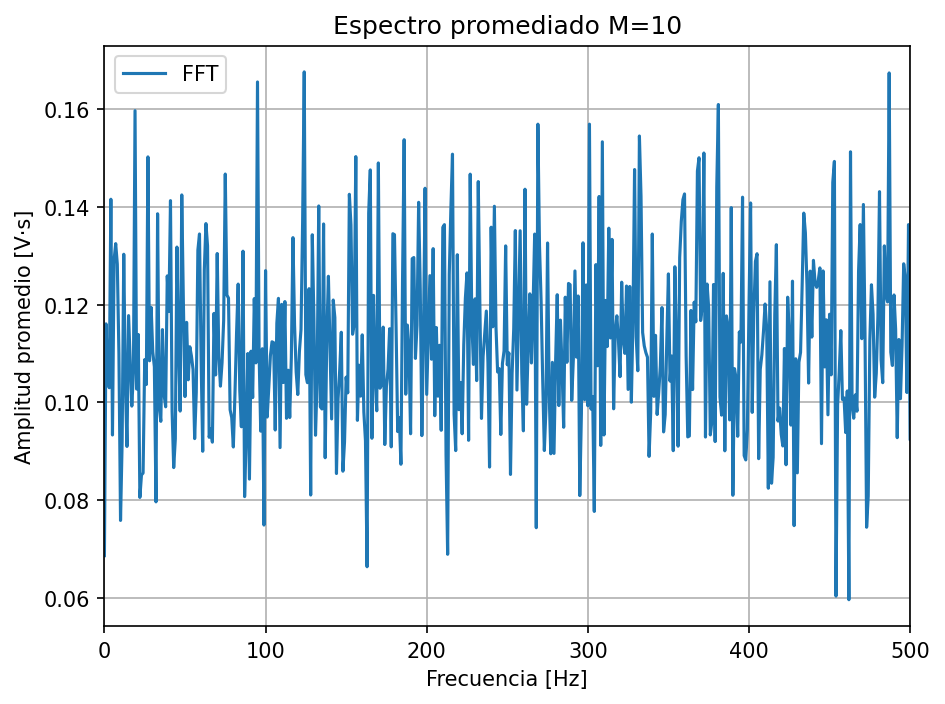

In [33]:

N=1000
fs   = N #Resolucion espectral normalizada
deltaf=fs/N
vsigma= 2
vmed = 0

freq = np.arange(start=0, stop=fs, step=deltaf)



spec_avg  = espectro_promediado(10, N=N, fs=fs)
plt.figure(dpi=150)
plt.title("Espectro promediado M=10")
plt.plot(freq, spec_avg, label=f"FFT")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud promedio [V·s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

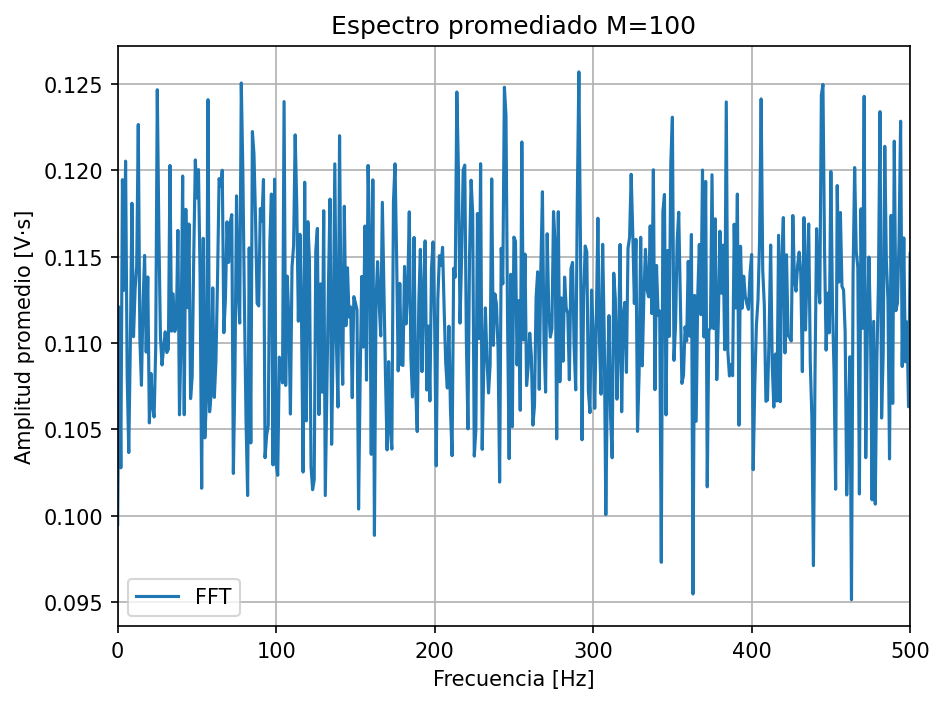

In [34]:

spec_avg  = espectro_promediado(100, N=N, fs=fs)
plt.figure(dpi=150)
plt.title("Espectro promediado M=100")
plt.plot(freq, spec_avg, label=f"FFT")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud promedio [V·s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

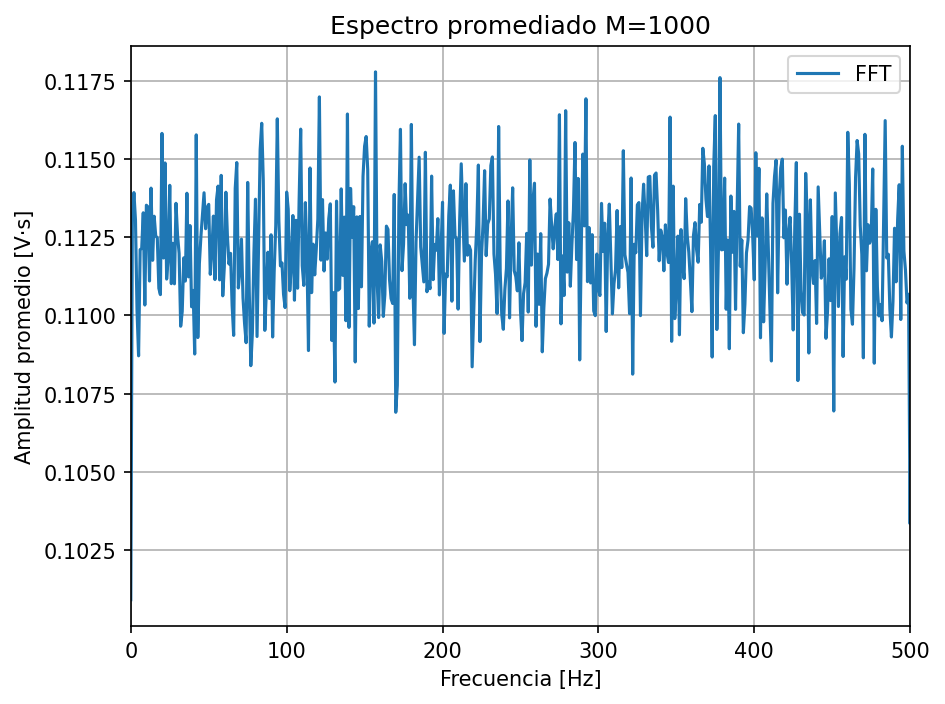

In [35]:

spec_avg  = espectro_promediado(1000, N=N, fs=fs)
plt.figure(dpi=150)
plt.title("Espectro promediado M=1000")
plt.plot(freq, spec_avg, label=f"FFT")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud promedio [V·s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

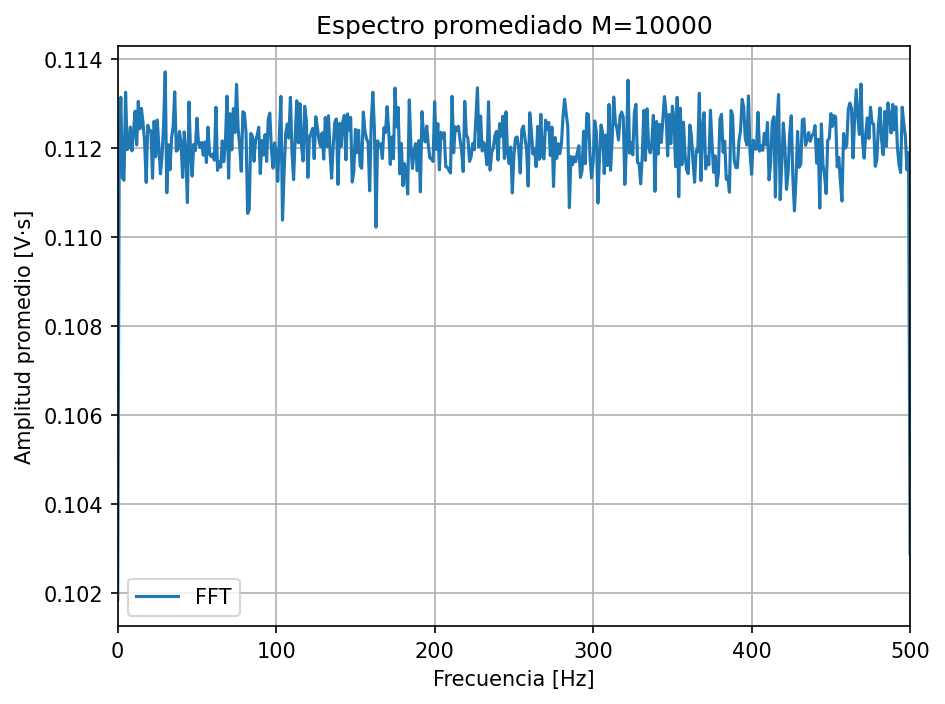

In [36]:

spec_avg  = espectro_promediado(10000, N=N, fs=fs)
plt.figure(dpi=150)
plt.title("Espectro promediado M=10000")
plt.plot(freq, spec_avg, label=f"FFT")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud promedio [V·s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

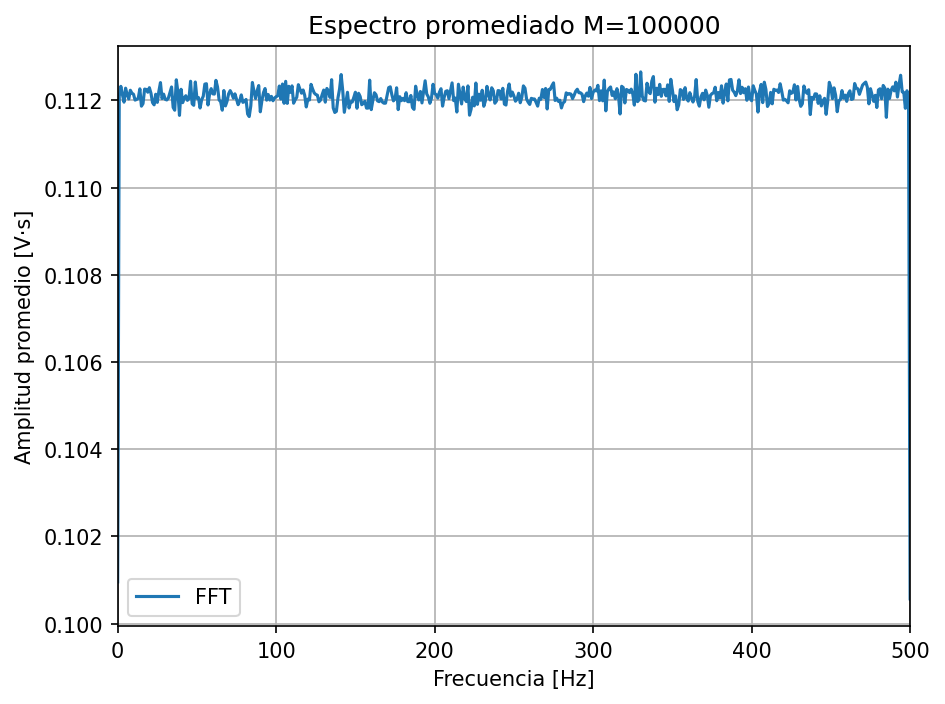

In [37]:

spec_avg  = espectro_promediado(100000, N=N, fs=fs)
plt.figure(dpi=150)
plt.title("Espectro promediado M=100000")
plt.plot(freq, spec_avg, label=f"FFT")
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud promedio [V·s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Se puede ver como el promediado de varios espectros tiende a un espectro plano.

Estuve investigando si el valor al que tendia el promedio de los espectros era a uno comun y encontre esta formula que da una muy buena aproximacion del espectro esperado

$$E[|X[k]|] = \sqrt{\frac{N\sigma^2}{2}} \cdot \sqrt{\frac{\pi}{2}} = \frac{\sigma\sqrt{N\pi}}{2}$$


$$E\!\left[\frac{2\,|X[k]|}{N}\right] = \frac{2}{N} \cdot \frac{\sigma\sqrt{N\pi}}{2} = \frac{\sigma\sqrt{\pi}}{\sqrt{N}}$$

En nuestro caso da:

$$E\!\left[\frac{2\,|X[k]|}{N}\right] = \frac{2\sqrt{\pi}}{\sqrt{1000}} \approx 0.1121 \text{ V·s}$$

La estadistica y la probabilidad combinadas con FFT parecen magia.

#### Extra DFT/FFT Cuadrada con valor medio

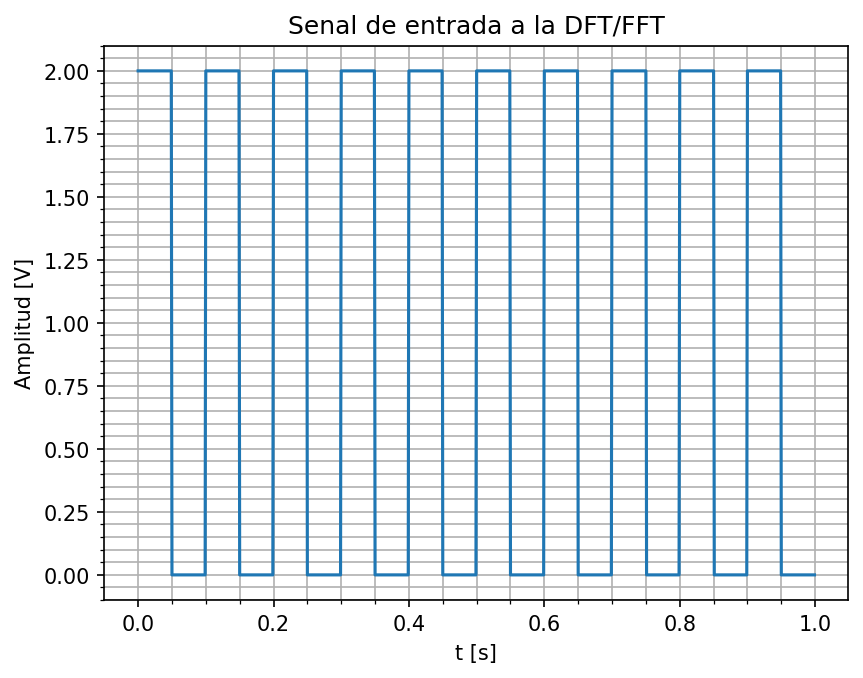

In [47]:
N=1000
fs   = N #Resolucion espectral normalizada
deltaf=fs/N
ff = deltaf*10

t, x = mi_funcion( vmax = 1, dc = 1, ff = ff, ph = 0, nn = N, fs = fs, type_s = 'square')
plt.figure(dpi=150)
plt.plot(t,x)
plt.minorticks_on()
#plt.xlim([0, 3/ff])
plt.xlabel('t [s]')
plt.ylabel('Amplitud [V]')
plt.title('Senal de entrada a la DFT/FFT')
plt.grid(which = 'major', linestyle = '-', linewidth = 0.8)
plt.grid(which = 'minor', linestyle = '-', linewidth = 0.8)

In [48]:

inicio = time.time()

Xk = DFT(x)

fin = time.time()

timedft = fin - inicio

print(f"Tiempo de ejecución DFT: {fin - inicio:.9f} segundos")


inicio = time.time()

Xft = fft(x)

fin = time.time()

timefft = fin - inicio

print(f"Tiempo de ejecución FFT: {fin - inicio:.9f} segundos")

print(f"Ganancia de Procecsamiento: {timedft/timefft:.9f}")

Tiempo de ejecución DFT: 0.075323582 segundos
Tiempo de ejecución FFT: 0.000222445 segundos
Ganancia de Procecsamiento: 338.617363344


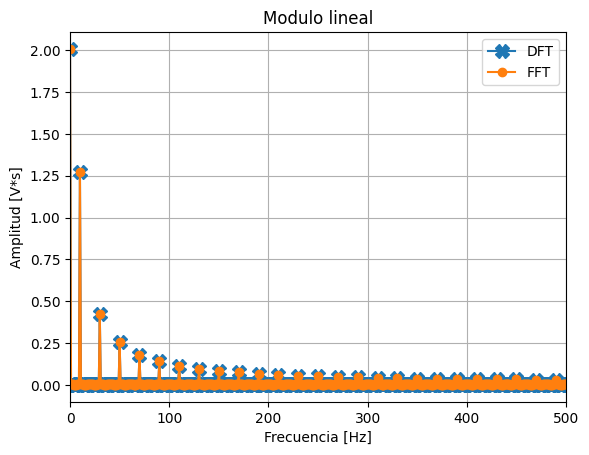

In [49]:
freq= np.arange(start = 0, stop = fs, step = deltaf)

plt.figure()
plt.title("Modulo lineal")
plt.plot(freq,2*np.abs(Xk)/len(Xk), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,2*np.abs(Xft)/len(Xft), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [V*s]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()

/tmp/ipykernel_460803/590370169.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.plot(freq,20*np.log10(2*np.abs(Xft)/len(Xft)), label= "FFT", marker = 'o')


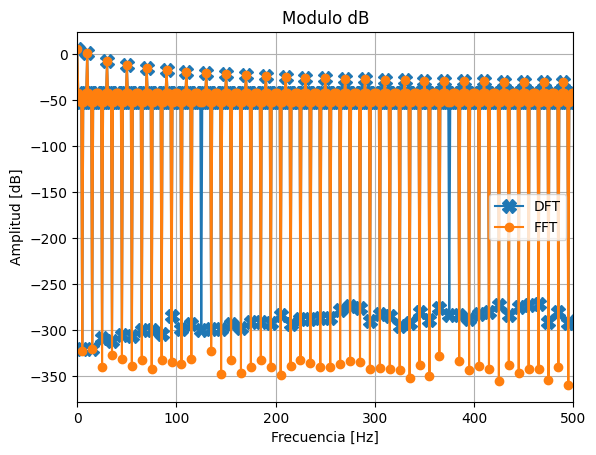

In [50]:
plt.figure()
plt.title("Modulo dB")
plt.plot(freq,20*np.log10(2*np.abs(Xk)/len(Xk)), label= "DFT" , marker = 'X',markersize= 10)
plt.plot(freq,20*np.log10(2*np.abs(Xft)/len(Xft)), label= "FFT", marker = 'o')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.xlim(0, fs//2)
plt.grid()
plt.legend()